## Реализация k-Means

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, calinski_harabasz_score, v_measure_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import BayesianGaussianMixture
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering

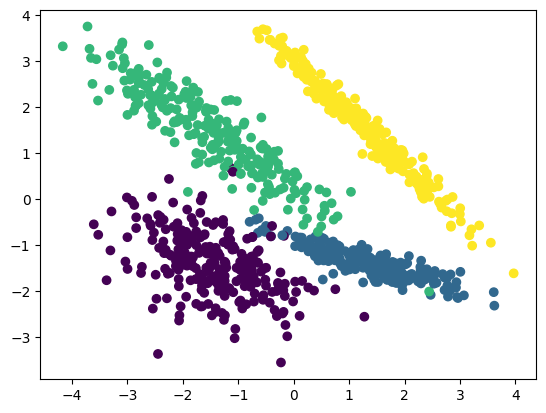

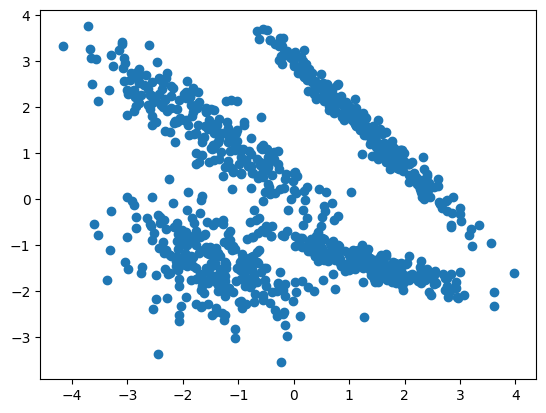

In [2]:
x_1, y_1 = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=1.4,
    n_redundant = 0,
    flip_y=0, 
    random_state=17
)

plt.scatter(x_1[:, 0], x_1[:, 1], c=y_1)
plt.show()

plt.scatter(x_1[:, 0], x_1[:, 1])
plt.show()

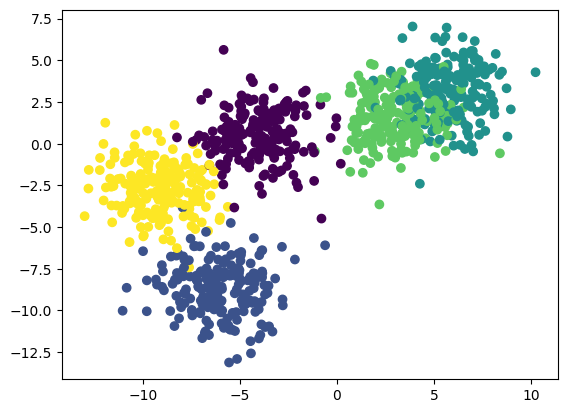

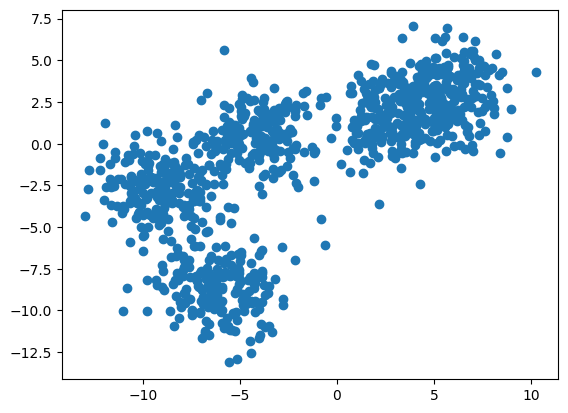

In [3]:
x_2, y_2 = make_blobs(
    n_samples=1000,
    n_features=2, 
    centers=5,
    shuffle=True,
    random_state=17,
    cluster_std=1.5
)

plt.scatter(x_2[:, 0], x_2[:, 1], c=y_2)
plt.show()

plt.scatter(x_2[:, 0], x_2[:, 1])
plt.show()

In [4]:
data = pd.read_csv('../data/credit_card_fraud_filtered.csv')

data_subset = data.head(50_000).copy()

y_3 = data_subset['fraud']
x_3 = data_subset.drop('fraud', axis=1)

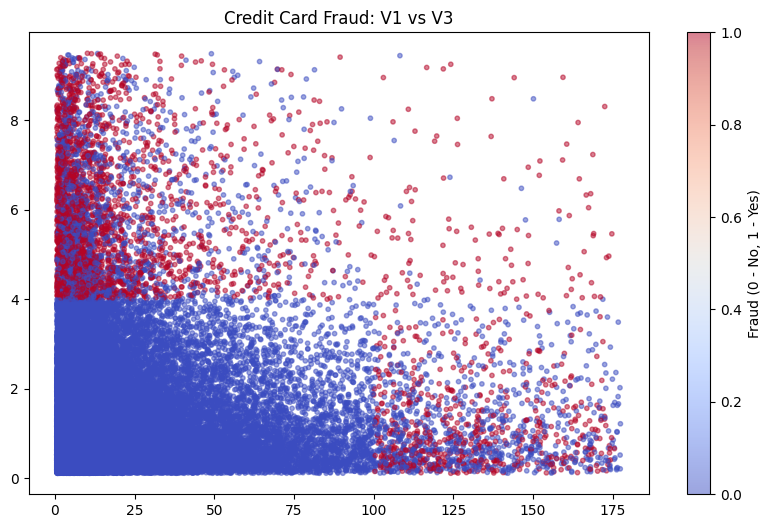

In [5]:

plt.figure(figsize=(10, 6))
plt.scatter(x_3.values[:, 0], x_3.values[:, 2], c=y_3, cmap='coolwarm', s=10, alpha=0.5)
plt.colorbar(label='Fraud (0 - No, 1 - Yes)')
plt.title('Credit Card Fraud: V1 vs V3')
plt.show()

In [6]:
x_3_col = x_3.columns
x_1 = StandardScaler().fit_transform(x_1)
x_2 = StandardScaler().fit_transform(x_2)
x_3 = StandardScaler().fit_transform(x_3)

x_1 = pd.DataFrame(x_1, columns=['feature_1', 'feature_2'])
x_2 = pd.DataFrame(x_2, columns=['feature_1', 'feature_2'])
x_3 = pd.DataFrame(x_3, columns=x_3_col)

In [7]:
results = []

def metrics(x, labels, y, algorithm_name, dataset_name):
    calinski_harabasz = calinski_harabasz_score(x, labels) 
    sil_score = silhouette_score(x, labels)
    v_score = v_measure_score(y, labels)
    adjusted_rand = adjusted_rand_score(y, labels)

    metrics_for_trial = {
        'Algorithm': algorithm_name,
        'Data': dataset_name,
        'Silhouette': round(sil_score, 4),
        'Calinski-Harabasz': round(calinski_harabasz, 4),
        'V-Measure': round(v_score, 4),
        'ARI': round(adjusted_rand, 4)
    }

    return metrics_for_trial


In [ ]:
def Kmeans(array, k, max_iter=1000, tol=1e-4):      # tol - порог сходимости
    data = np.array(array)
    n = data.shape[0]
    
    indices = np.random.choice(n, size=k, replace=False)    # k случайных индексов из диапазона от 0 до n без повторений
    centroids = data[indices].tolist()
    
    for _ in range(max_iter):
        labels = data_distribution(data, centroids)
        
        old_centroids = copy.deepcopy(centroids)    # deepcopy нужен, чтобы изменение списка centroids не затронуло old_centroids
        
        centroids = cluster_update(data, labels, k)
        
        if np.allclose(old_centroids, centroids, atol=tol):
            break
    
    return labels, centroids

def data_distribution(data, centroids):     # вычисляем евклидово расстояние от точки до конкретного центра c
    return [np.argmin([np.linalg.norm(point - c) for c in centroids]) 
            for point in data]

def cluster_update(data, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = data[labels == i]
        if len(cluster_points) == 0:        # если к центру никто не «пришел», мы принудительно переносим его на координаты любой случайной точки из датасета
            new_centroids.append(data[np.random.randint(len(data))].tolist())
            continue
        new_centroids.append(cluster_points.mean(axis=0).tolist())
    return new_centroids

Кластер 0: число наблюдений 208
Кластер 1: число наблюдений 180
Кластер 2: число наблюдений 401
Кластер 3: число наблюдений 211


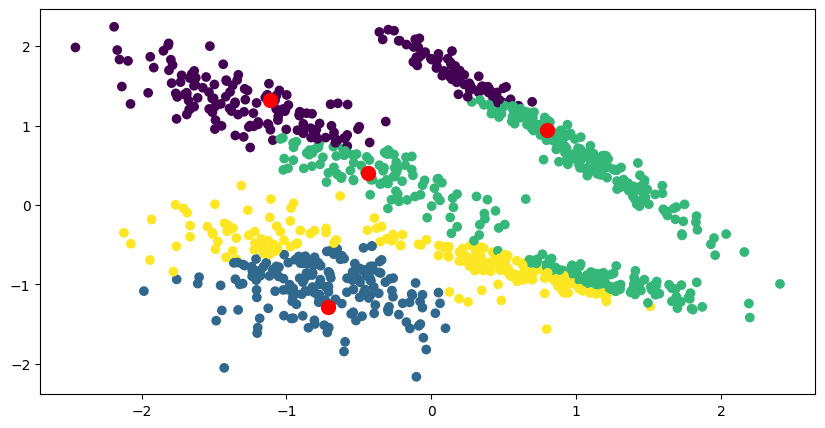

Кластер 0: число наблюдений 460
Кластер 1: число наблюдений 184
Кластер 2: число наблюдений 201
Кластер 3: число наблюдений 155


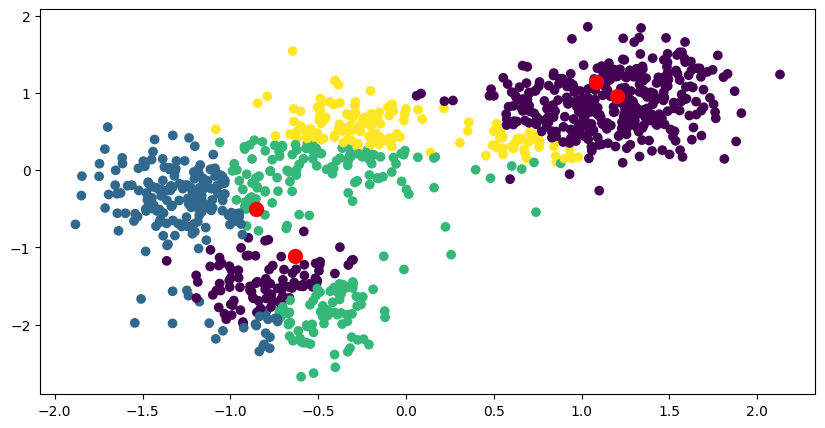

Кластер 0: число наблюдений 14689
Кластер 1: число наблюдений 11129
Кластер 2: число наблюдений 2639
Кластер 3: число наблюдений 21543


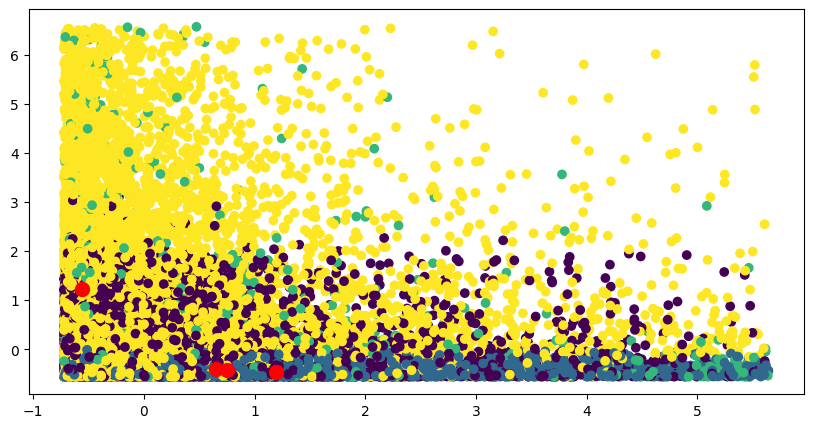

In [20]:
x = [x_1, x_2, x_3]
y = [y_1, y_2, y_3]
dataset_names = ['make_classification', 'make_blobs', 'credit_card_fraud']

for i in range(len(x)):
    data = x[i]
    labels, centroids = Kmeans(data, 4, 1000)

    centroids = np.array(centroids)

    metrics_result = metrics(
        x=data, 
        labels=labels, 
        y=y[i], 
        algorithm_name="KMeans", 
        dataset_name=dataset_names[i]
    )
    results.append(metrics_result)
   
    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=labels)
    plt.scatter(centroids[:,0], centroids[:,1], s=100, c='red')
    plt.show()

In [10]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.3627,695.5563,0.4805,0.3826
1,KMeans,make_blobs,0.3272,1121.7783,0.6004,0.4705
2,KMeans,credit_card_fraud,-0.0081,2676.1177,0.0193,-0.0291
